# Exploratory Data Analysis (EDA)
## Dataset: previous_application

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `previous_application` dataset from the Home Credit risk modeling case. This table contains all previous loan applications submitted by clients who have a current loan in the sample, serving as a behavioral history signal for predicting default on the current application.

---

## 🎯 Objectives
- Understand the structure and characteristics of the `previous_application` dataset
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (distribution of individual variables)
- Bivariate analysis (relationships between features)
- Aggregation strategy (previous_application to SK_ID_CURR)
- Bivariate analysis of aggregated features vs TARGET
- Initial business-driven interpretation of previous application behavior

---

## 🧠 Key Questions
- What is the previous application profile of current loan applicants?
- How do approval status and contract type of previous applications relate to default behavior?
- What aggregated signals from previous applications are most predictive of default?
- Are there patterns in refused or cancelled applications that differentiate defaulters?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## 📊 Output
The output of this EDA will serve as:
- Aggregated previous application features ready for merging into the main modeling table
- Business insights on previous application behavior
- Input for feature selection and credit scoring models

# Importing Library

In [1]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math


# Importing Dataset

In [3]:
# Dataset previous_application
previous_application_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\previous_application.csv'
df_prev = pd.read_csv(previous_application_path)

# Dataset application_train (for bivariate aggregated features vs TARGET)
application_train_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train_path)

# 1. About Dataset

The dataset consists of **1,670,214 observations** and **37 features**, representing all previous loan applications submitted by clients who have a current loan in the sample. Each row corresponds to a single previous application linked to an applicant in the main dataset via `SK_ID_CURR`.

The features can be grouped into several categories:
- **Key identifiers**: `SK_ID_PREV` (previous application ID) and `SK_ID_CURR` (link to main table)
- **Numerical features**: application and credit amounts, down payment, interest rates, and temporal variables (in days)
- **Categorical features**: contract type, contract status, payment type, rejection reason, and various product/channel descriptors
- **Flag features**: indicators for last application per contract and insurance status

In [4]:
df_prev.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  str    
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  str    
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  str    
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-null   float6

# 2. Contract Status Distribution

The contract status distribution shows the outcome of all previous loan applications submitted by current applicants. Understanding the proportion of approved, refused, and cancelled applications provides an initial signal of the credit behavior and risk profile of applicants.

- Total Approved: 1,036,781 (~62.07%)
- Total Canceled: 316,319 (~18.94%)
- Total Refused: 290,678 (~17.40%)
- Total Unused offer: 26,436 (~1.58%)

The majority of previous applications were **Approved (~62.07%)**, indicating that most applicants have a history of successful credit applications. However, a combined **36.34%** of applications were either Cancelled or Refused, which may carry meaningful risk signal. Refused applications in particular suggest prior credit rejections that could be predictive of current default behavior.

In [6]:
# Contract status value counts
print(df_prev['NAME_CONTRACT_STATUS'].value_counts())
print(f"\nContract Status Distribution (%):")
print((df_prev['NAME_CONTRACT_STATUS'].value_counts() / len(df_prev) * 100).round(2))


NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

Contract Status Distribution (%):
NAME_CONTRACT_STATUS
Approved        62.07
Canceled        18.94
Refused         17.40
Unused offer     1.58
Name: count, dtype: float64


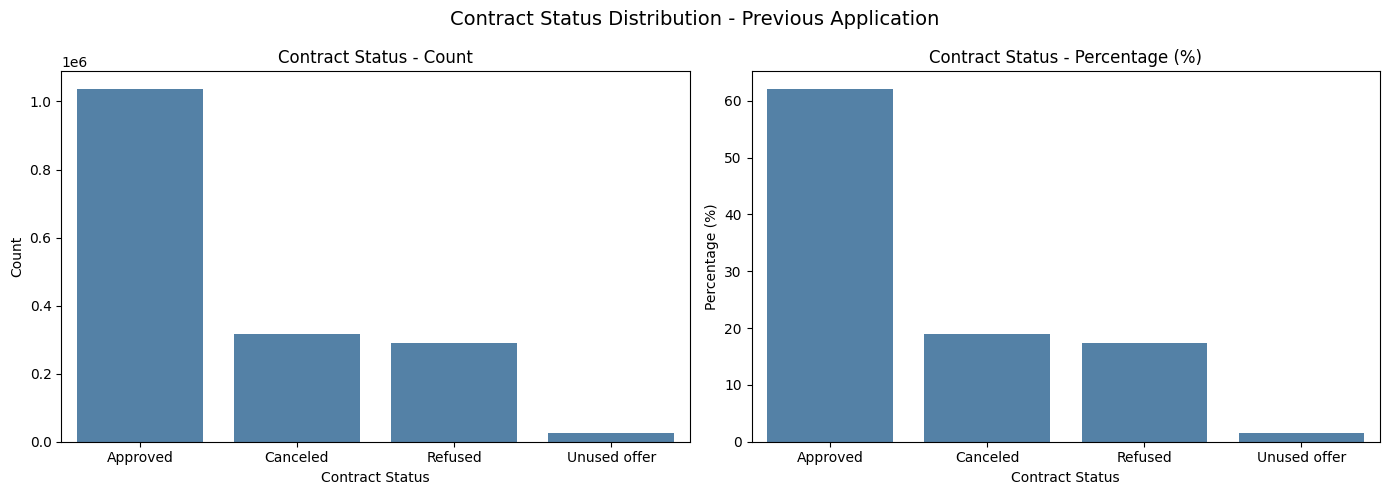

In [7]:
# Bar plot - contract status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
contract_status_counts = df_prev['NAME_CONTRACT_STATUS'].value_counts()
sns.barplot(x=contract_status_counts.index, y=contract_status_counts.values, ax=axes[0], color='steelblue')
axes[0].set_title('Contract Status - Count')
axes[0].set_xlabel('Contract Status')
axes[0].set_ylabel('Count')

# Percentage plot
contract_status_pct = df_prev['NAME_CONTRACT_STATUS'].value_counts(normalize=True) * 100
sns.barplot(x=contract_status_pct.index, y=contract_status_pct.values, ax=axes[1], color='steelblue')
axes[1].set_title('Contract Status - Percentage (%)')
axes[1].set_xlabel('Contract Status')
axes[1].set_ylabel('Percentage (%)')

plt.suptitle('Contract Status Distribution - Previous Application', fontsize=14)
plt.tight_layout()
plt.show()


# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature
- **Evaluating** the likely cause of missingness based on domain context
- **Defining** a handling strategy for each missing feature

The results of this analysis serve as recommendations for the data handling stage, including imputing values and deciding whether missingness itself carries meaningful signal.

In [8]:
# Missing value count and percentage
missing_prev = pd.DataFrame({
    'Missing Count': df_prev.isnull().sum(),
    'Missing (%)': (df_prev.isnull().sum() / len(df_prev) * 100).round(2)
})
missing_prev = missing_prev[missing_prev['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)
print(missing_prev)


                           Missing Count  Missing (%)
RATE_INTEREST_PRIVILEGED         1664263        99.64
RATE_INTEREST_PRIMARY            1664263        99.64
AMT_DOWN_PAYMENT                  895844        53.64
RATE_DOWN_PAYMENT                 895844        53.64
NAME_TYPE_SUITE                   820405        49.12
DAYS_LAST_DUE                     673065        40.30
DAYS_FIRST_DRAWING                673065        40.30
DAYS_FIRST_DUE                    673065        40.30
DAYS_TERMINATION                  673065        40.30
NFLAG_INSURED_ON_APPROVAL         673065        40.30
DAYS_LAST_DUE_1ST_VERSION         673065        40.30
AMT_GOODS_PRICE                   385515        23.08
CNT_PAYMENT                       372230        22.29
AMT_ANNUITY                       372235        22.29
PRODUCT_COMBINATION                  346         0.02
AMT_CREDIT                             1         0.00


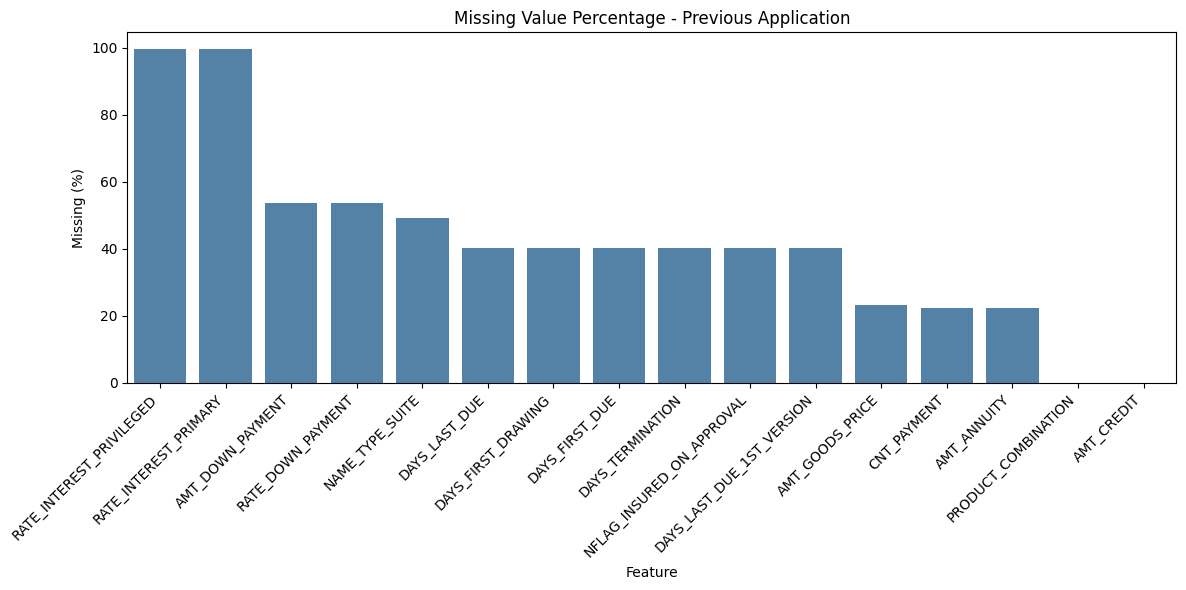

In [9]:
# Visualization of missing values
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_prev.index, y=missing_prev['Missing (%)'], color='steelblue')
plt.title('Missing Value Percentage - Previous Application')
plt.ylabel('Missing (%)')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Findings & Handling Strategy

The `previous_application` dataset contains **16 features with missing values**, spanning both numerical and categorical types.

Key observations:
- `RATE_INTEREST_PRIVILEGED` and `RATE_INTEREST_PRIMARY` (99.64%) are almost entirely missing, likely only applicable to a specific loan product. These features carry minimal signal and are candidates for removal.
- `AMT_DOWN_PAYMENT` and `RATE_DOWN_PAYMENT` (53.64%) are missing for applications without a down payment requirement, likely non-revolving or cash loan types. Missing likely indicates absence rather than unknown value.
- `NAME_TYPE_SUITE` (49.12%) is a categorical feature with high missingness, likely not recorded for all application channels.
- `DAYS_LAST_DUE`, `DAYS_FIRST_DRAWING`, `DAYS_FIRST_DUE`, `DAYS_TERMINATION`, `NFLAG_INSURED_ON_APPROVAL`, `DAYS_LAST_DUE_1ST_VERSION` (40.30%) are all missing for the same subset of records, likely applications that were not approved and therefore have no disbursement schedule.
- `AMT_GOODS_PRICE` (23.08%), `CNT_PAYMENT` (22.29%), and `AMT_ANNUITY` (22.29%) have moderate missing rates, likely tied to specific contract types.
- `PRODUCT_COMBINATION` (0.02%) and `AMT_CREDIT` (0.00%) have negligible missing values.

**Handling Strategy:**
- `RATE_INTEREST_PRIVILEGED`, `RATE_INTEREST_PRIMARY`: consider **dropping** due to 99.64% missing rate and limited signal
- `AMT_DOWN_PAYMENT`, `RATE_DOWN_PAYMENT`: impute with **0**, missing indicates no down payment
- `DAYS_LAST_DUE`, `DAYS_FIRST_DRAWING`, `DAYS_FIRST_DUE`, `DAYS_TERMINATION`, `DAYS_LAST_DUE_1ST_VERSION`: impute with **0**, missing indicates application was not approved
- `NFLAG_INSURED_ON_APPROVAL`: impute with **0**, missing indicates no insurance on approval
- `NAME_TYPE_SUITE`: impute with **'Unknown'**, missing likely reflects unreported accompaniment
- `AMT_GOODS_PRICE`, `CNT_PAYMENT`, `AMT_ANNUITY`: impute with **median** per `NAME_CONTRACT_TYPE` group
- `PRODUCT_COMBINATION`, `AMT_CREDIT`: impute with **mode** and **median** respectively

---

# 4. Numerical Features Analysis

Numerical features in `previous_application` are analyzed to understand their distributions, central tendencies, and relationships. This section covers both univariate and bivariate analysis before aggregation.

The approach includes:
- **Describing** each feature through summary statistics
- **Visualizing** distributions to detect skewness and anomalies
- **Detecting** outliers using boxplots
- **Examining** pairwise correlations between numerical features

In [ ]:
# Numerical features in previous_application (exclude identifiers)
num_cols_prev = df_prev.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_prev = [col for col in num_cols_prev if col not in ['SK_ID_PREV', 'SK_ID_CURR']]

## 4.1 Univariate Analysis

Univariate analysis examines each numerical feature independently to understand its distribution, central tendency, and spread. This serves as the foundation before exploring relationships between features.

The approach includes:
- **Describing** each feature through summary statistics (mean, median, std, min, max)
- **Identifying** potential anomalies, skewness, and extreme values

### 4.1.1 Statistical Descriptive

In [ ]:
# Statistical description
df_prev[num_cols_prev].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_ANNUITY,1297979.0,15955.120659,14782.137335,0.000000,6321.780000,11250.000000,20658.420000,418058.145
AMT_APPLICATION,1670214.0,175233.860360,292779.762386,0.000000,18720.000000,71046.000000,180360.000000,6905160.000
AMT_CREDIT,1670213.0,196114.021218,318574.616547,0.000000,24160.500000,80541.000000,216418.500000,6905160.000
AMT_DOWN_PAYMENT,774370.0,6697.402139,20921.495410,-0.900000,0.000000,1638.000000,7740.000000,3060045.000
AMT_GOODS_PRICE,1284699.0,227847.279283,315396.557937,0.000000,50841.000000,112320.000000,234000.000000,6905160.000
HOUR_APPR_PROCESS_START,1670214.0,12.484182,3.334028,0.000000,10.000000,12.000000,15.000000,23.000
NFLAG_LAST_APPL_IN_DAY,1670214.0,0.996468,0.059330,0.000000,1.000000,1.000000,1.000000,1.000
RATE_DOWN_PAYMENT,774370.0,0.079637,0.107823,-0.000015,0.000000,0.051605,0.108909,1.000
RATE_INTEREST_PRIMARY,5951.0,0.188357,0.087671,0.034781,0.160716,0.189122,0.193330,1.000
RATE_INTEREST_PRIVILEGED,5951.0,0.773503,0.100879,0.373150,0.715645,0.835095,0.852537,1.000


#### Key Findings

**Days Features (Negative Values by Design)**
`DAYS_DECISION` is negative by design, representing days relative to application date. No transformation needed in EDA.

**Anomalies Detected**
- `DAYS_FIRST_DRAWING`, `DAYS_FIRST_DUE`, `DAYS_LAST_DUE_1ST_VERSION`, `DAYS_LAST_DUE`, `DAYS_TERMINATION` all have max = **365,243**, the same encoding anomaly seen in `DAYS_EMPLOYED` in `application_train`. This value flags applications with no actual disbursement schedule and requires special handling.
- `AMT_DOWN_PAYMENT` min = **-0.90** and `RATE_DOWN_PAYMENT` min = **-0.000015**, negative values are not meaningful and require investigation.
- `SELLERPLACE_AREA` min = **-1**, likely an encoding for unknown or not applicable, and max = **4,000,000** is an extreme outlier.

**Skewed Distributions**
- `AMT_APPLICATION`, `AMT_CREDIT`, `AMT_GOODS_PRICE` are heavily right-skewed, log transformation or capping recommended.
- `AMT_ANNUITY` mean 15,955 vs median 11,250, moderately right-skewed.
- `AMT_DOWN_PAYMENT` median = 0 with max 3,060,045, heavily right-skewed.

**Near-Zero Variance**
- `NFLAG_LAST_APPL_IN_DAY` mean = 0.996, almost constant. Limited predictive value.

**Sparse Features**
- `RATE_INTEREST_PRIMARY` and `RATE_INTEREST_PRIVILEGED` only 5,951 non-null (0.36% coverage), consistent with 99.64% missing rate confirmed earlier.
- `DAYS_FIRST_DRAWING` median = 365,243, majority of non-null values are the anomaly encoding, making this feature unreliable in raw form.

**Features for Further Analysis**
- `AMT_APPLICATION`, `AMT_CREDIT`, `AMT_GOODS_PRICE` to confirm skewness and outlier severity
- `DAYS_DECISION` to examine distribution of previous application recency
- `DAYS_FIRST_DRAWING`, `DAYS_LAST_DUE` to confirm extent of 365,243 anomaly
- `SELLERPLACE_AREA` to investigate extreme outlier and -1 encoding

---

### 4.1.2 Distribution Plot

Distribution plots are used to examine the shape of each numerical feature - whether it is normally distributed, right-skewed, or contains anomalies. Features with high skewness may require log transformation during preprocessing.

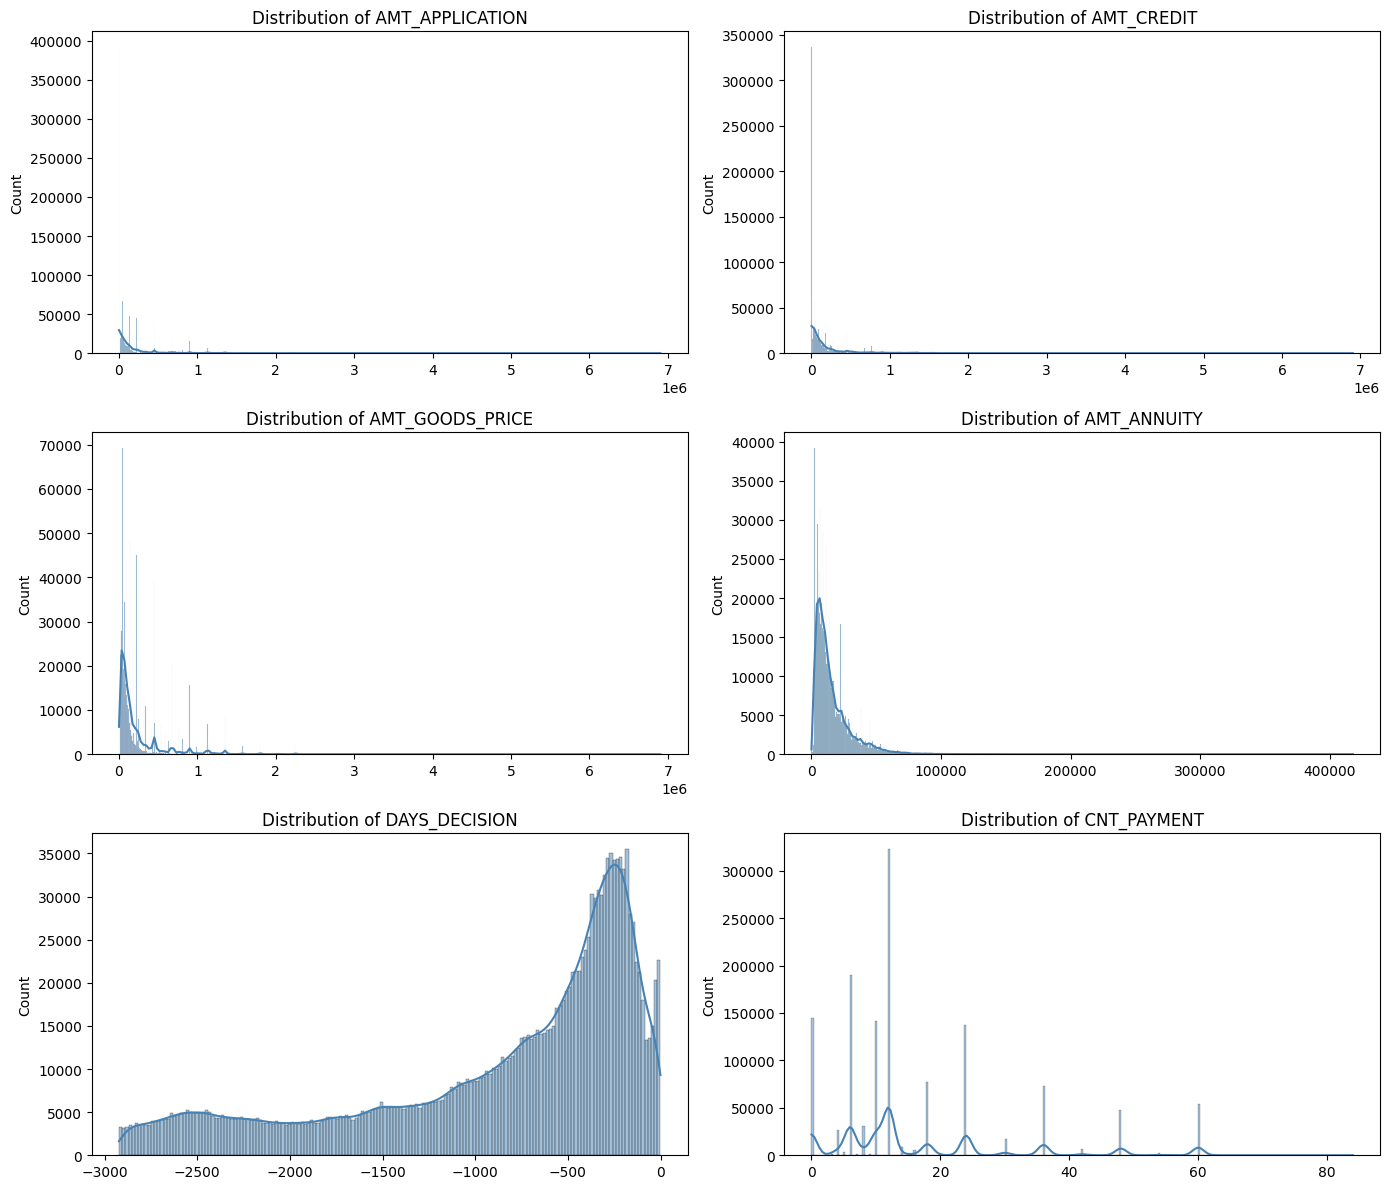

In [11]:
# Select key numerical features for distribution analysis
num_features_dist = [
    'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_GOODS_PRICE',
    'AMT_ANNUITY', 'DAYS_DECISION', 'CNT_PAYMENT'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_features_dist):
    sns.histplot(df_prev[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#### Key Findings

- `AMT_APPLICATION` and `AMT_CREDIT` are extremely right-skewed with the vast majority of values compressed near zero and long tails extending to 6.9M. **Log transformation or capping recommended.**
- `AMT_GOODS_PRICE` shows a similar pattern with multiple small spikes suggesting discrete pricing tiers, followed by a long right tail. **Capping recommended.**
- `AMT_ANNUITY` is right-skewed with most values below 50,000 and a long tail extending to 418,000. **Capping recommended.**
- `DAYS_DECISION` shows a left-skewed distribution concentrated near 0, with most previous applications decided within the last 2 years before current application. Consistent with negative-by-design encoding.
- `CNT_PAYMENT` shows a discrete distribution with distinct spikes at multiples of 6 (6, 12, 24, 36), reflecting standard loan term structures. No anomalies detected.

---

### 4.1.3 Outlier Detection

Boxplots are used to detect outliers in numerical features. Extreme values can distort model training and may require capping or domain-aware treatment before modeling.

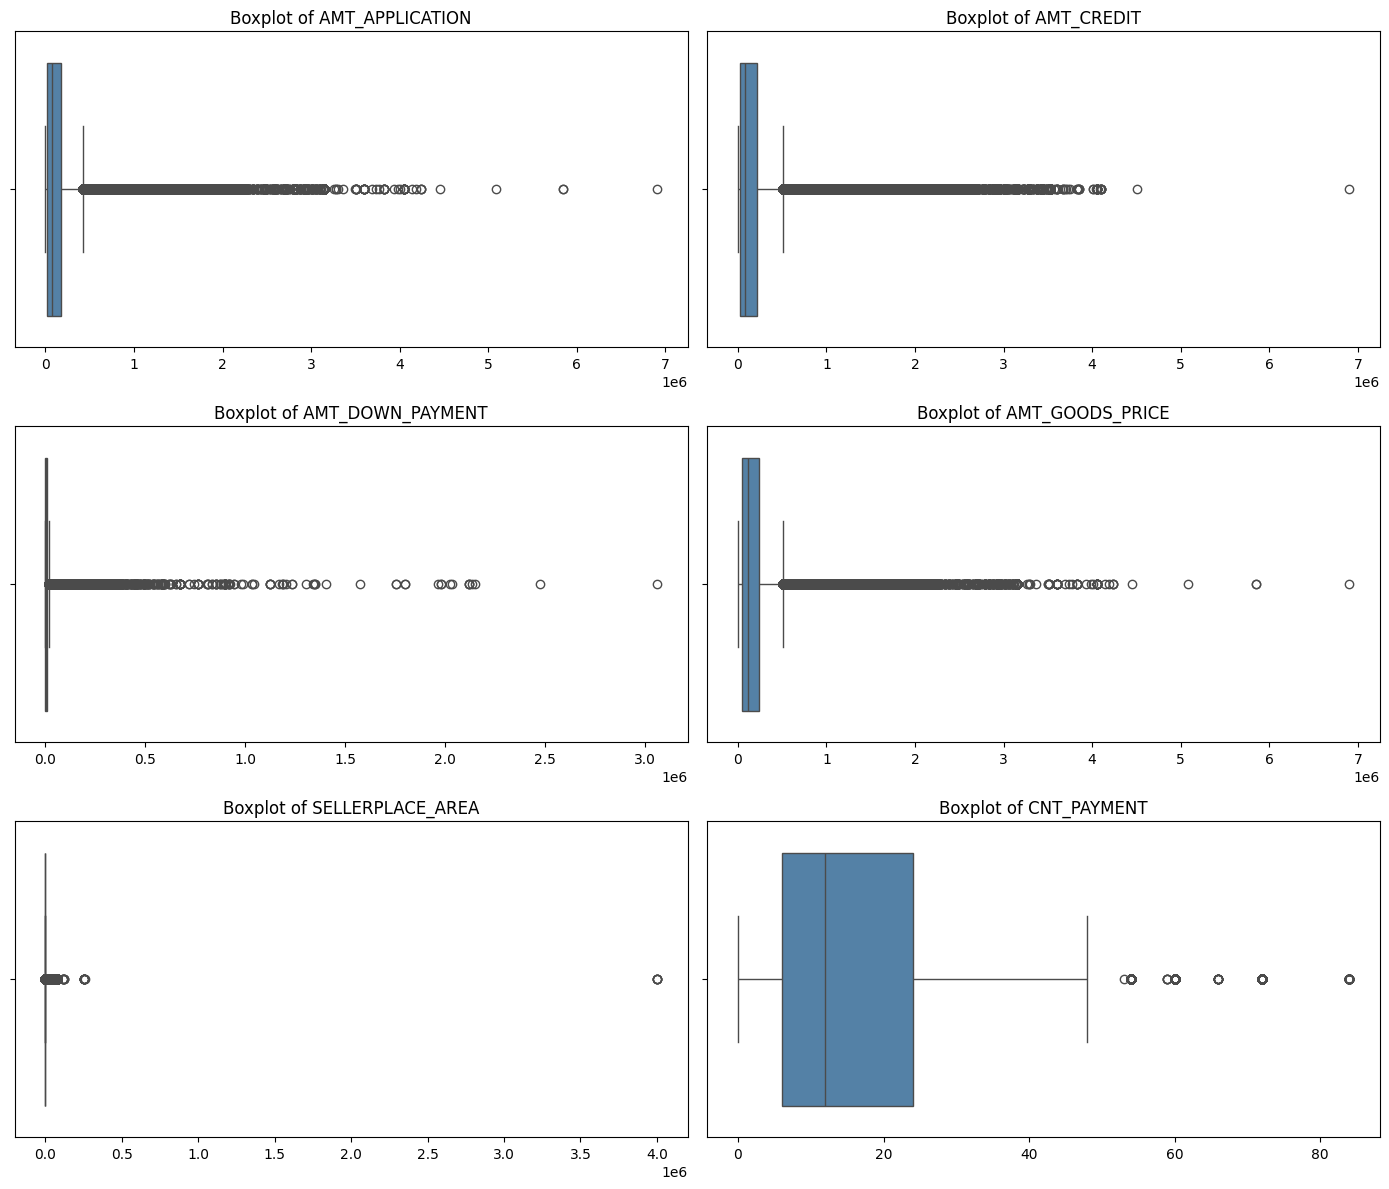

In [12]:
# Select key numerical features for outlier detection
outlier_features = [
    'AMT_APPLICATION', 'AMT_CREDIT',
    'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
    'SELLERPLACE_AREA', 'CNT_PAYMENT'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(x=df_prev[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#### Key Findings

- `AMT_APPLICATION` and `AMT_CREDIT` show extreme outliers far beyond the IQR extending to 6.9M, **needs capping.**
- `AMT_DOWN_PAYMENT` shows extreme outliers up to 3M with a negative value visible on the left, **needs capping and negative value handling.**
- `AMT_GOODS_PRICE` shows extreme outliers extending to 6.9M, **needs capping.**
- `SELLERPLACE_AREA` is almost entirely compressed near zero with one extreme outlier at 4,000,000, **needs special handling or capping.**
- `CNT_PAYMENT` shows moderate spread with sparse outliers above 60, reasonable range for loan terms.

All amount features require outlier treatment before aggregation and modeling. `SELLERPLACE_AREA` requires investigation of the -1 encoding and extreme outlier before use.

---

## 4.2 Bivariate Between Features

This section examines pairwise correlations between numerical features in `previous_application` to detect multicollinearity and identify redundant features before aggregation.

The approach includes:
- **Heatmap** to visualize pairwise correlation between numerical features

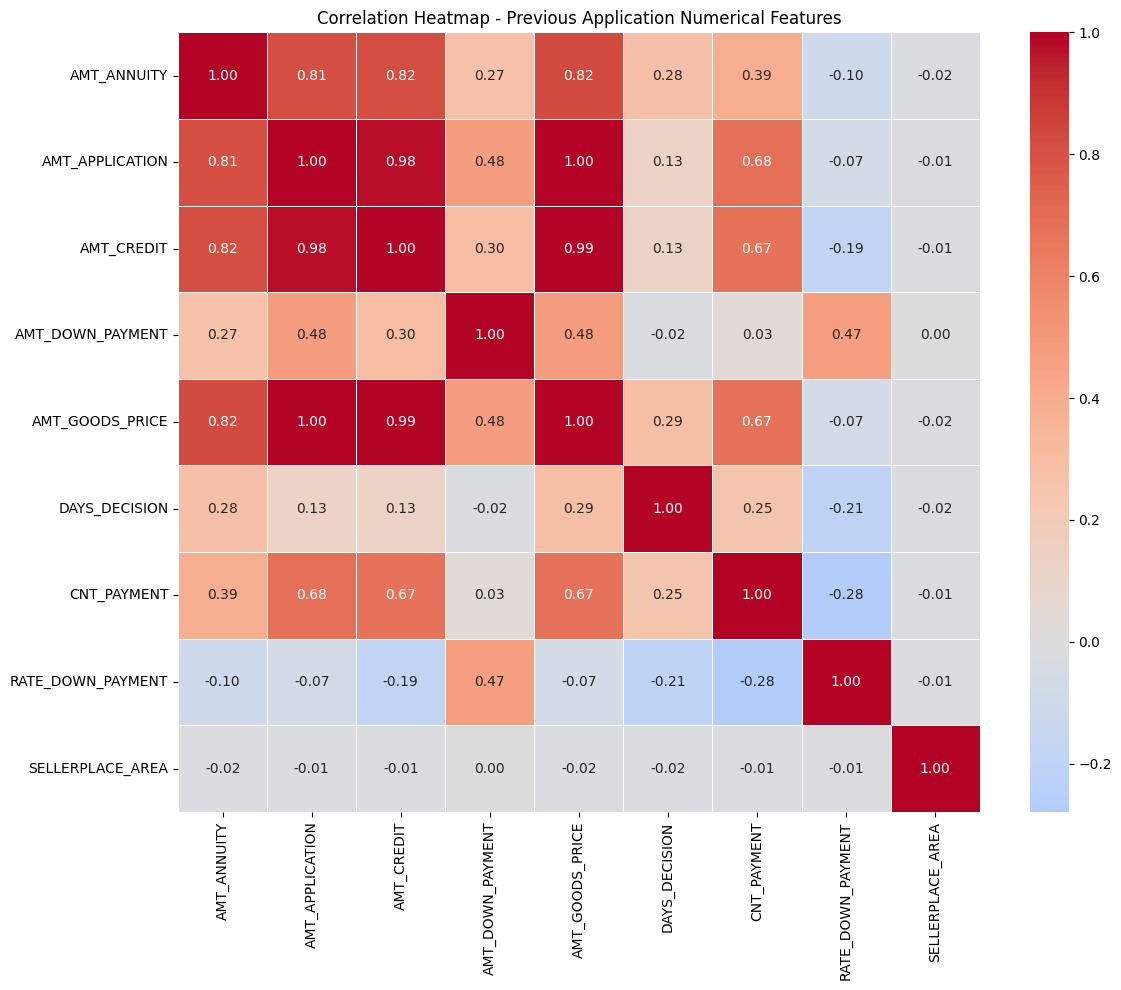

In [13]:
# Select relevant numerical features for correlation analysis
num_cols_corr = [
    'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT',
    'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
    'DAYS_DECISION', 'CNT_PAYMENT', 'RATE_DOWN_PAYMENT',
    'SELLERPLACE_AREA'
]

# Correlation heatmap - previous application numerical features
plt.figure(figsize=(12, 10))
corr_prev = df_prev[num_cols_corr].corr()
sns.heatmap(
    corr_prev,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap - Previous Application Numerical Features')
plt.tight_layout()
plt.show()

#### Key Findings

**Very High Multicollinearity: Amount Features**
`AMT_APPLICATION` and `AMT_GOODS_PRICE` are almost perfectly correlated (1.00), confirming they capture nearly identical information. `AMT_CREDIT` is also highly correlated with both (0.98-0.99). During feature engineering, consider retaining only one of these three, or deriving a ratio feature such as `AMT_CREDIT / AMT_APPLICATION` to capture credit-to-application spread.

**High Correlation: AMT_ANNUITY with Amount Features**
`AMT_ANNUITY` shows high correlation with `AMT_APPLICATION` (0.81), `AMT_CREDIT` (0.82), and `AMT_GOODS_PRICE` (0.82), which is expected as larger loans naturally require higher monthly payments. Can be retained but redundancy should be considered during feature selection.

**Moderate Correlation: CNT_PAYMENT with Amount Features**
`CNT_PAYMENT` shows moderate correlation with `AMT_APPLICATION` (0.68) and `AMT_GOODS_PRICE` (0.67), suggesting larger loan amounts tend to have longer repayment terms. Both can be retained as they capture different dimensions.

**RATE_DOWN_PAYMENT vs AMT_DOWN_PAYMENT**
Moderate correlation (0.47) between the rate and absolute amount of down payment. Both can be retained as they provide complementary perspectives on down payment behavior.

**SELLERPLACE_AREA is Independent**
Near-zero correlation with all other features, confirming it captures a completely independent dimension. Its usefulness after aggregation will depend on outlier treatment.

**Features to Watch During Aggregation**
- `AMT_APPLICATION`, `AMT_CREDIT`, `AMT_GOODS_PRICE`: highly redundant, consider retaining only one or deriving ratio features
- `AMT_ANNUITY` and `CNT_PAYMENT`: retain both as they capture loan structure dimensions

---

# 5. Categorical Features Analysis

## 5.1 Univariate Analysis

Univariate analysis for categorical features examines each feature independently
to understand its category distribution, frequency, and concentration.

The approach includes:
- **Describing** each feature through unique value counts, most frequent category, and its frequency percentage
- **Identifying** dominant categories, near-constant features, and rare categories that may need handling

### 5.1.1 Statistical Descriptive

In [14]:
# Select categorical features
cat_features_prev = df_prev.select_dtypes(include='object').columns

# Build summary: unique values, most frequent category, and its frequency
cat_summary_prev = pd.DataFrame({
    'Unique_Values': df_prev[cat_features_prev].nunique(),
    'Most_Frequent': df_prev[cat_features_prev].apply(lambda x: x.value_counts().index[0]),
    'Frequency': df_prev[cat_features_prev].apply(lambda x: x.value_counts().iloc[0]),
    'Frequency_%': df_prev[cat_features_prev].apply(
        lambda x: (x.value_counts().iloc[0] / x.count() * 100).round(2)
    )
})

cat_summary_prev

,Unique_Values,Most_Frequent,Frequency,Frequency_%
NAME_CONTRACT_TYPE,4,Cash loans,747553,44.76
WEEKDAY_APPR_PROCESS_START,7,TUESDAY,255118,15.27
FLAG_LAST_APPL_PER_CONTRACT,2,Y,1661739,99.49
NAME_CASH_LOAN_PURPOSE,25,XAP,922661,55.24
NAME_CONTRACT_STATUS,4,Approved,1036781,62.07
NAME_PAYMENT_TYPE,4,Cash through the bank,1033552,61.88
CODE_REJECT_REASON,9,XAP,1353093,81.01
NAME_TYPE_SUITE,7,Unaccompanied,508970,59.89
NAME_CLIENT_TYPE,4,Repeater,1231261,73.72
NAME_GOODS_CATEGORY,28,XNA,950809,56.93


In [15]:
# Looking for values from each feature
for col in df_prev.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df_prev[col].value_counts())


NAME_CONTRACT_TYPE:
NAME_CONTRACT_TYPE
Cash loans         747553
Consumer loans     729151
Revolving loans    193164
XNA                   346
Name: count, dtype: int64

WEEKDAY_APPR_PROCESS_START:
WEEKDAY_APPR_PROCESS_START
TUESDAY      255118
WEDNESDAY    255010
MONDAY       253557
FRIDAY       252048
THURSDAY     249099
SATURDAY     240631
SUNDAY       164751
Name: count, dtype: int64

FLAG_LAST_APPL_PER_CONTRACT:
FLAG_LAST_APPL_PER_CONTRACT
Y    1661739
N       8475
Name: count, dtype: int64

NAME_CASH_LOAN_PURPOSE:
NAME_CASH_LOAN_PURPOSE
XAP                                 922661
XNA                                 677918
Repairs                              23765
Other                                15608
Urgent needs                          8412
Buying a used car                     2888
Building a house or an annex          2693
Everyday expenses                     2416
Medicine                              2174
Payments on other loans               1931
Education           

##### Key Findings

**Near-Constant Features**
- `FLAG_LAST_APPL_PER_CONTRACT` is 99.49% `Y`, almost constant. Limited predictive value and can be considered for dropping.
- `CODE_REJECT_REASON` is 81.01% `XAP` (not applicable, i.e. approved applications), heavily dominated by non-rejected records.

**High XNA/XAP Dominance**
- `NAME_CASH_LOAN_PURPOSE` is 55.24% `XAP` and 40.60% `XNA`, leaving only ~4% with meaningful purpose labels.
- `NAME_GOODS_CATEGORY` is 56.93% `XNA`, applicable only to consumer loan types.
- `NAME_SELLER_INDUSTRY` is 51.23% `XNA`, similarly limited to specific loan types.
- `NAME_PRODUCT_TYPE` is 63.68% `XNA`. These XNA-dominated features may have limited signal after aggregation.

**High Cardinality**
- `NAME_GOODS_CATEGORY` has 28 unique categories, `PRODUCT_COMBINATION` has 17, and `NAME_CASH_LOAN_PURPOSE` has 25. Consider grouping rare categories before modeling.

**Rare Categories Needing Handling**
- `NAME_CONTRACT_TYPE` contains `XNA` with only 346 rows, replace with mode or group into Other.
- `NAME_CLIENT_TYPE` contains `XNA` with only 1,941 rows, replace with mode.
- `NAME_PAYMENT_TYPE` contains `XNA` with 627,384 rows (37.56%), likely tied to non-cash loan types.

**Notable Distributions**
- `NAME_CLIENT_TYPE` is 73.72% `Repeater`, indicating most previous applicants had prior interactions with Home Credit.
- `NAME_CONTRACT_STATUS` is 62.07% `Approved`, consistent with Section 2 findings.
- `WEEKDAY_APPR_PROCESS_START` is relatively evenly distributed across weekdays, with Sunday having noticeably fewer applications.

**Features for Further Analysis**
- `NAME_CONTRACT_TYPE`, `NAME_CONTRACT_STATUS`, `CODE_REJECT_REASON` to explore default rate differences
- `NAME_CLIENT_TYPE` to check if repeat vs new clients differ in default risk
- `NAME_YIELD_GROUP` to examine relationship between interest rate tier and default behavior
- `CHANNEL_TYPE` to investigate if acquisition channel correlates with default risk

---

### 5.1.2 Frequency Plot

Bar plots are used to visualize the frequency distribution of each categorical feature.
This helps identify dominant categories, class imbalance within features,
and rare categories that may need grouping before modeling.

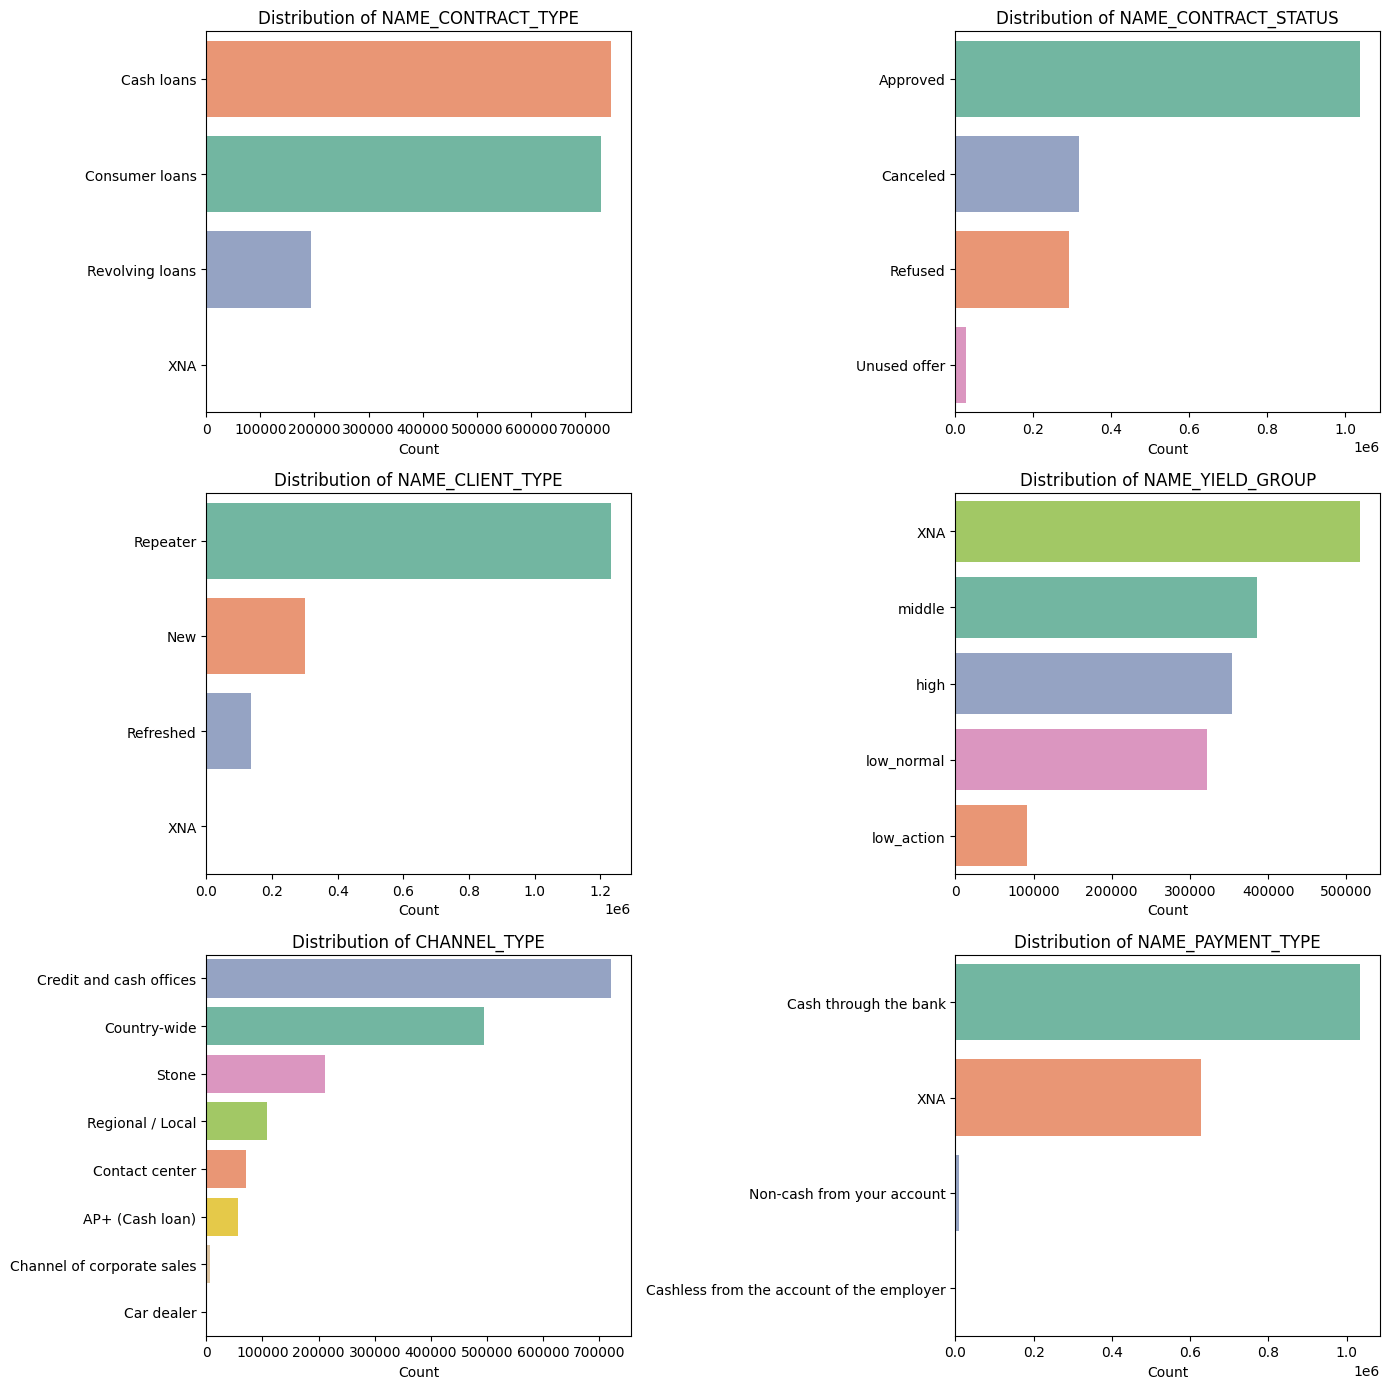

In [16]:
# Select categorical features with sufficient variation for analysis
cat_features_plot = [
    'NAME_CONTRACT_TYPE', 'NAME_CONTRACT_STATUS',
    'NAME_CLIENT_TYPE', 'NAME_YIELD_GROUP',
    'CHANNEL_TYPE', 'NAME_PAYMENT_TYPE'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features_plot):
    order = df_prev[col].value_counts().index
    sns.countplot(
        data=df_prev, y=col,
        order=order, ax=axes[i],
        hue=col, palette='Set2', legend=False
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

##### Key Findings

**NAME_CONTRACT_TYPE**
Cash loans (~748k) and Consumer loans (~729k) dominate in roughly equal proportions, with Revolving loans as a distant third (~193k). XNA has only 346 records and should be replaced with mode or dropped before modeling.

**NAME_CONTRACT_STATUS**
Approved applications dominate at ~1M records, with Canceled and Refused roughly equal at ~316k and ~291k respectively. Unused offer is negligible at ~26k. Consistent with Section 2 findings.

**NAME_CLIENT_TYPE**
Repeater clients overwhelmingly dominate (~1.2M), confirming most applicants have prior history with Home Credit. New clients (~301k) and Refreshed (~136k) are minority groups. XNA is negligible with only 1,941 records.

**NAME_YIELD_GROUP**
XNA dominates (~517k), followed by relatively even distribution across middle, high, and low_normal tiers. low_action has notably fewer records (~92k). XNA likely corresponds to cash loan types where yield group is not applicable.

**CHANNEL_TYPE**
Credit and cash offices (~720k) and Country-wide (~495k) together account for over 73% of applications. Remaining channels including Stone, Regional/Local, and Contact center have moderate counts. Car dealer is negligible.

**NAME_PAYMENT_TYPE**
Cash through the bank dominates (~1M), with XNA accounting for ~627k (likely non-applicable for certain loan types). Non-cash and Cashless options are practically invisible, suggesting payment diversity is very limited.

---

## 5.2 Bivariate Between Features

This section examines the relationship between categorical features in `previous_application`
to identify patterns and associations before aggregation.

The approach includes:
- **Evaluating** default rate differences across categories after joining with TARGET
- **Identifying** high-risk and low-risk groups within each categorical feature

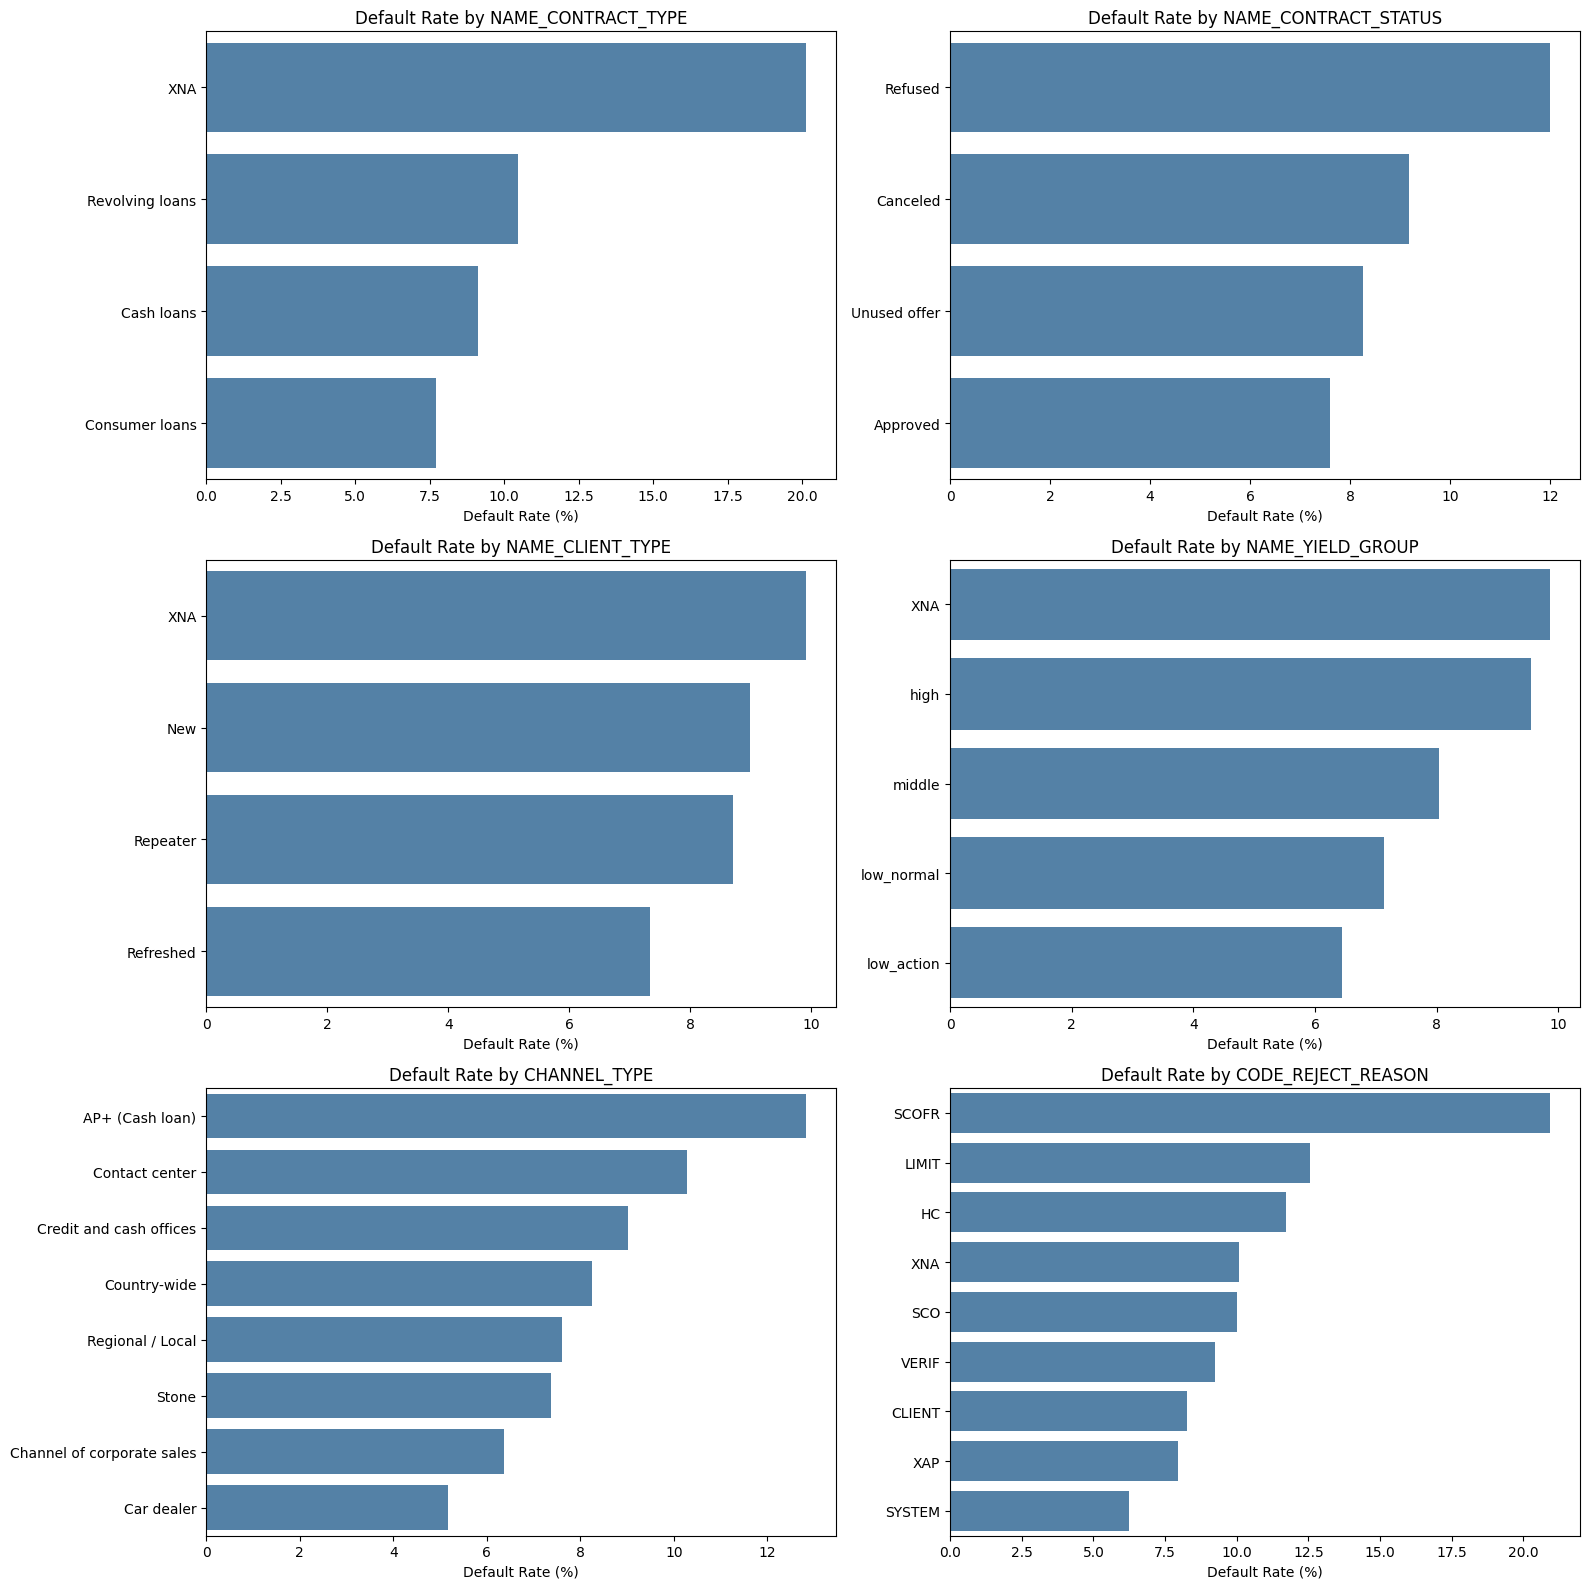

In [17]:
# Join previous_application with TARGET from app_train
df_prev_target = df_prev.merge(
    df_app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

# Select categorical features for default rate analysis
cat_features_bivar = [
    'NAME_CONTRACT_TYPE', 'NAME_CONTRACT_STATUS',
    'NAME_CLIENT_TYPE', 'NAME_YIELD_GROUP',
    'CHANNEL_TYPE', 'CODE_REJECT_REASON'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(cat_features_bivar):
    default_rate = df_prev_target.groupby(col)['TARGET'].mean() * 100
    default_rate = default_rate.sort_values(ascending=False)
    sns.barplot(x=default_rate.values, y=default_rate.index,
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

##### Key Findings

**NAME_CONTRACT_TYPE**
`XNA` shows the highest default rate (~20%) but represents only 346 records and should be handled before modeling. Among meaningful categories, `Revolving loans` (~10%) and `Cash loans` (~9%) show higher default rates than `Consumer loans` (~8%), suggesting consumer loan applicants are relatively lower risk.

**NAME_CONTRACT_STATUS**
`Refused` applications show the highest default rate (~12%), followed by `Canceled` (~9%) and `Unused offer` (~8%). Applicants whose previous applications were refused carry higher current default risk, confirming prior rejection history as a meaningful signal. `Approved` shows the lowest rate (~8%).

**NAME_CLIENT_TYPE**
`New` clients show higher default rate (~9%) compared to `Repeater` (~8%) and `Refreshed` (~7%). Returning clients with prior Home Credit history tend to be lower risk, suggesting relationship history is a mild but meaningful signal.

**NAME_YIELD_GROUP**
Clear inverse relationship between interest rate tier and default risk. `high` yield group (~10%) shows the highest default rate while `low_action` (~6%) shows the lowest. Higher interest rate tiers are associated with higher-risk borrower profiles, confirming yield group as a useful predictive feature.

**CHANNEL_TYPE**
`AP+ (Cash loan)` (~13%) and `Contact center` (~11%) show notably higher default rates compared to other channels. `Car dealer` shows the lowest rate (~5%), suggesting channel of acquisition carries meaningful risk signal worth preserving during aggregation.

**CODE_REJECT_REASON**
`SCOFR` (score fraud, ~21%) and `LIMIT` (credit limit exceeded, ~14%) show the highest default rates among rejection reasons. `HC` (high credit, ~13%) also shows elevated risk. Even among approved applicants (`XAP`, ~8%), the distribution confirms that rejection reason history is a strong predictor of current default behavior.

---

# Aggregation

This section aggregates `previous_application` into applicant-level features ready for merging into the main modeling table. Aggregation is performed in a single step directly to `SK_ID_CURR` level.

The approach includes:
- **Aggregating** `previous_application` to `SK_ID_CURR` level to derive applicant-level previous application behavior features

## Previous Application to SK_ID_CURR

Previous application records are aggregated to applicant level using `SK_ID_CURR` as the key. This produces one row per applicant containing summarized previous application features ready for merging into `application_train`.

In [18]:
# Aggregate previous_application to SK_ID_CURR level
df_prev_agg = df_prev.groupby('SK_ID_CURR').agg(
    # Application count
    PREV_COUNT=('SK_ID_PREV', 'count'),

    # Days features
    PREV_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    PREV_DAYS_DECISION_MIN=('DAYS_DECISION', 'min'),
    PREV_DAYS_DECISION_MAX=('DAYS_DECISION', 'max'),

    # Amount features
    PREV_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    PREV_AMT_ANNUITY_MAX=('AMT_ANNUITY', 'max'),
    PREV_AMT_APPLICATION_MEAN=('AMT_APPLICATION', 'mean'),
    PREV_AMT_APPLICATION_SUM=('AMT_APPLICATION', 'sum'),
    PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    PREV_AMT_CREDIT_SUM=('AMT_CREDIT', 'sum'),
    PREV_AMT_DOWN_PAYMENT_MEAN=('AMT_DOWN_PAYMENT', 'mean'),
    PREV_AMT_GOODS_PRICE_MEAN=('AMT_GOODS_PRICE', 'mean'),
    PREV_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
    PREV_CNT_PAYMENT_SUM=('CNT_PAYMENT', 'sum'),

    # Contract status counts
    PREV_APPROVED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_CANCELED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
    PREV_UNUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Unused offer').sum()),

    # Contract type counts
    PREV_CASH_COUNT=('NAME_CONTRACT_TYPE', lambda x: (x == 'Cash loans').sum()),
    PREV_CONSUMER_COUNT=('NAME_CONTRACT_TYPE', lambda x: (x == 'Consumer loans').sum()),
    PREV_REVOLVING_COUNT=('NAME_CONTRACT_TYPE', lambda x: (x == 'Revolving loans').sum()),

    # Client type
    PREV_REPEATER_COUNT=('NAME_CLIENT_TYPE', lambda x: (x == 'Repeater').sum()),
    PREV_NEW_COUNT=('NAME_CLIENT_TYPE', lambda x: (x == 'New').sum()),

    # Yield group
    PREV_YIELD_HIGH_COUNT=('NAME_YIELD_GROUP', lambda x: (x == 'high').sum()),
    PREV_YIELD_LOW_ACTION_COUNT=('NAME_YIELD_GROUP', lambda x: (x == 'low_action').sum()),

    # Channel type
    PREV_CHANNEL_AP_COUNT=('CHANNEL_TYPE', lambda x: (x == 'AP+ (Cash loan)').sum()),

    # Rate features
    PREV_RATE_DOWN_PAYMENT_MEAN=('RATE_DOWN_PAYMENT', 'mean'),
).reset_index()

# Proportion features
df_prev_agg['PREV_PROP_APPROVED'] = (df_prev_agg['PREV_APPROVED_COUNT'] / df_prev_agg['PREV_COUNT']).round(4)
df_prev_agg['PREV_PROP_REFUSED'] = (df_prev_agg['PREV_REFUSED_COUNT'] / df_prev_agg['PREV_COUNT']).round(4)
df_prev_agg['PREV_PROP_CANCELED'] = (df_prev_agg['PREV_CANCELED_COUNT'] / df_prev_agg['PREV_COUNT']).round(4)

# Credit to application ratio
df_prev_agg['PREV_CREDIT_TO_APPLICATION_RATIO'] = (
    df_prev_agg['PREV_AMT_CREDIT_MEAN'] / df_prev_agg['PREV_AMT_APPLICATION_MEAN']
).round(4)

print("Shape df_prev_agg:", df_prev_agg.shape)
df_prev_agg.head()

Shape df_prev_agg: (338857, 32)


,SK_ID_CURR,PREV_COUNT,PREV_DAYS_DECISION_MEAN,PREV_DAYS_DECISION_MIN,PREV_DAYS_DECISION_MAX,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_SUM,PREV_AMT_CREDIT_MEAN,...,PREV_REPEATER_COUNT,PREV_NEW_COUNT,PREV_YIELD_HIGH_COUNT,PREV_YIELD_LOW_ACTION_COUNT,PREV_CHANNEL_AP_COUNT,PREV_RATE_DOWN_PAYMENT_MEAN,PREV_PROP_APPROVED,PREV_PROP_REFUSED,PREV_PROP_CANCELED,PREV_CREDIT_TO_APPLICATION_RATIO
0,100001,1,-1740.0,-1740,-1740,3951.000,3951.000,24835.50,24835.5,23787.00,...,0,0,1,0,0,0.104326,1.0,0.0,0.0,0.9578
1,100002,1,-606.0,-606,-606,9251.775,9251.775,179055.00,179055.0,179055.00,...,0,1,0,0,0,0.000000,1.0,0.0,0.0,1.0000
2,100003,3,-1305.0,-2341,-746,56553.990,98356.995,435436.50,1306309.5,484191.00,...,1,0,0,0,0,0.050030,1.0,0.0,0.0,1.1120
3,100004,1,-815.0,-815,-815,5357.250,5357.250,24282.00,24282.0,20106.00,...,0,1,0,0,0,0.212008,1.0,0.0,0.0,0.8280
4,100005,2,-536.0,-757,-315,4813.200,4813.200,22308.75,44617.5,20076.75,...,1,1,1,0,0,0.108964,0.5,0.0,0.5,0.8999


In [ ]:
# Merge previous_application aggregations with application_train (LEFT)
df_prev_agg_target = df_prev_agg.merge(
    df_app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

print("Shape df_prev_agg_target:", df_prev_agg_target.shape)

Shape df_prev_agg_target: (338857, 33)


# 6. Bivariate Aggregated Features vs TARGET

This section examines the relationship between aggregated previous application features and the target variable (`TARGET`). The goal is to identify which aggregated features carry the strongest signal for predicting loan default.

The approach includes:
- **KDE plots** to compare distributions of aggregated numerical features between default and non-default applicants
- **Default rate plots** to evaluate default rate per category for aggregated categorical features

## 6.1 Numerical Aggregated Features

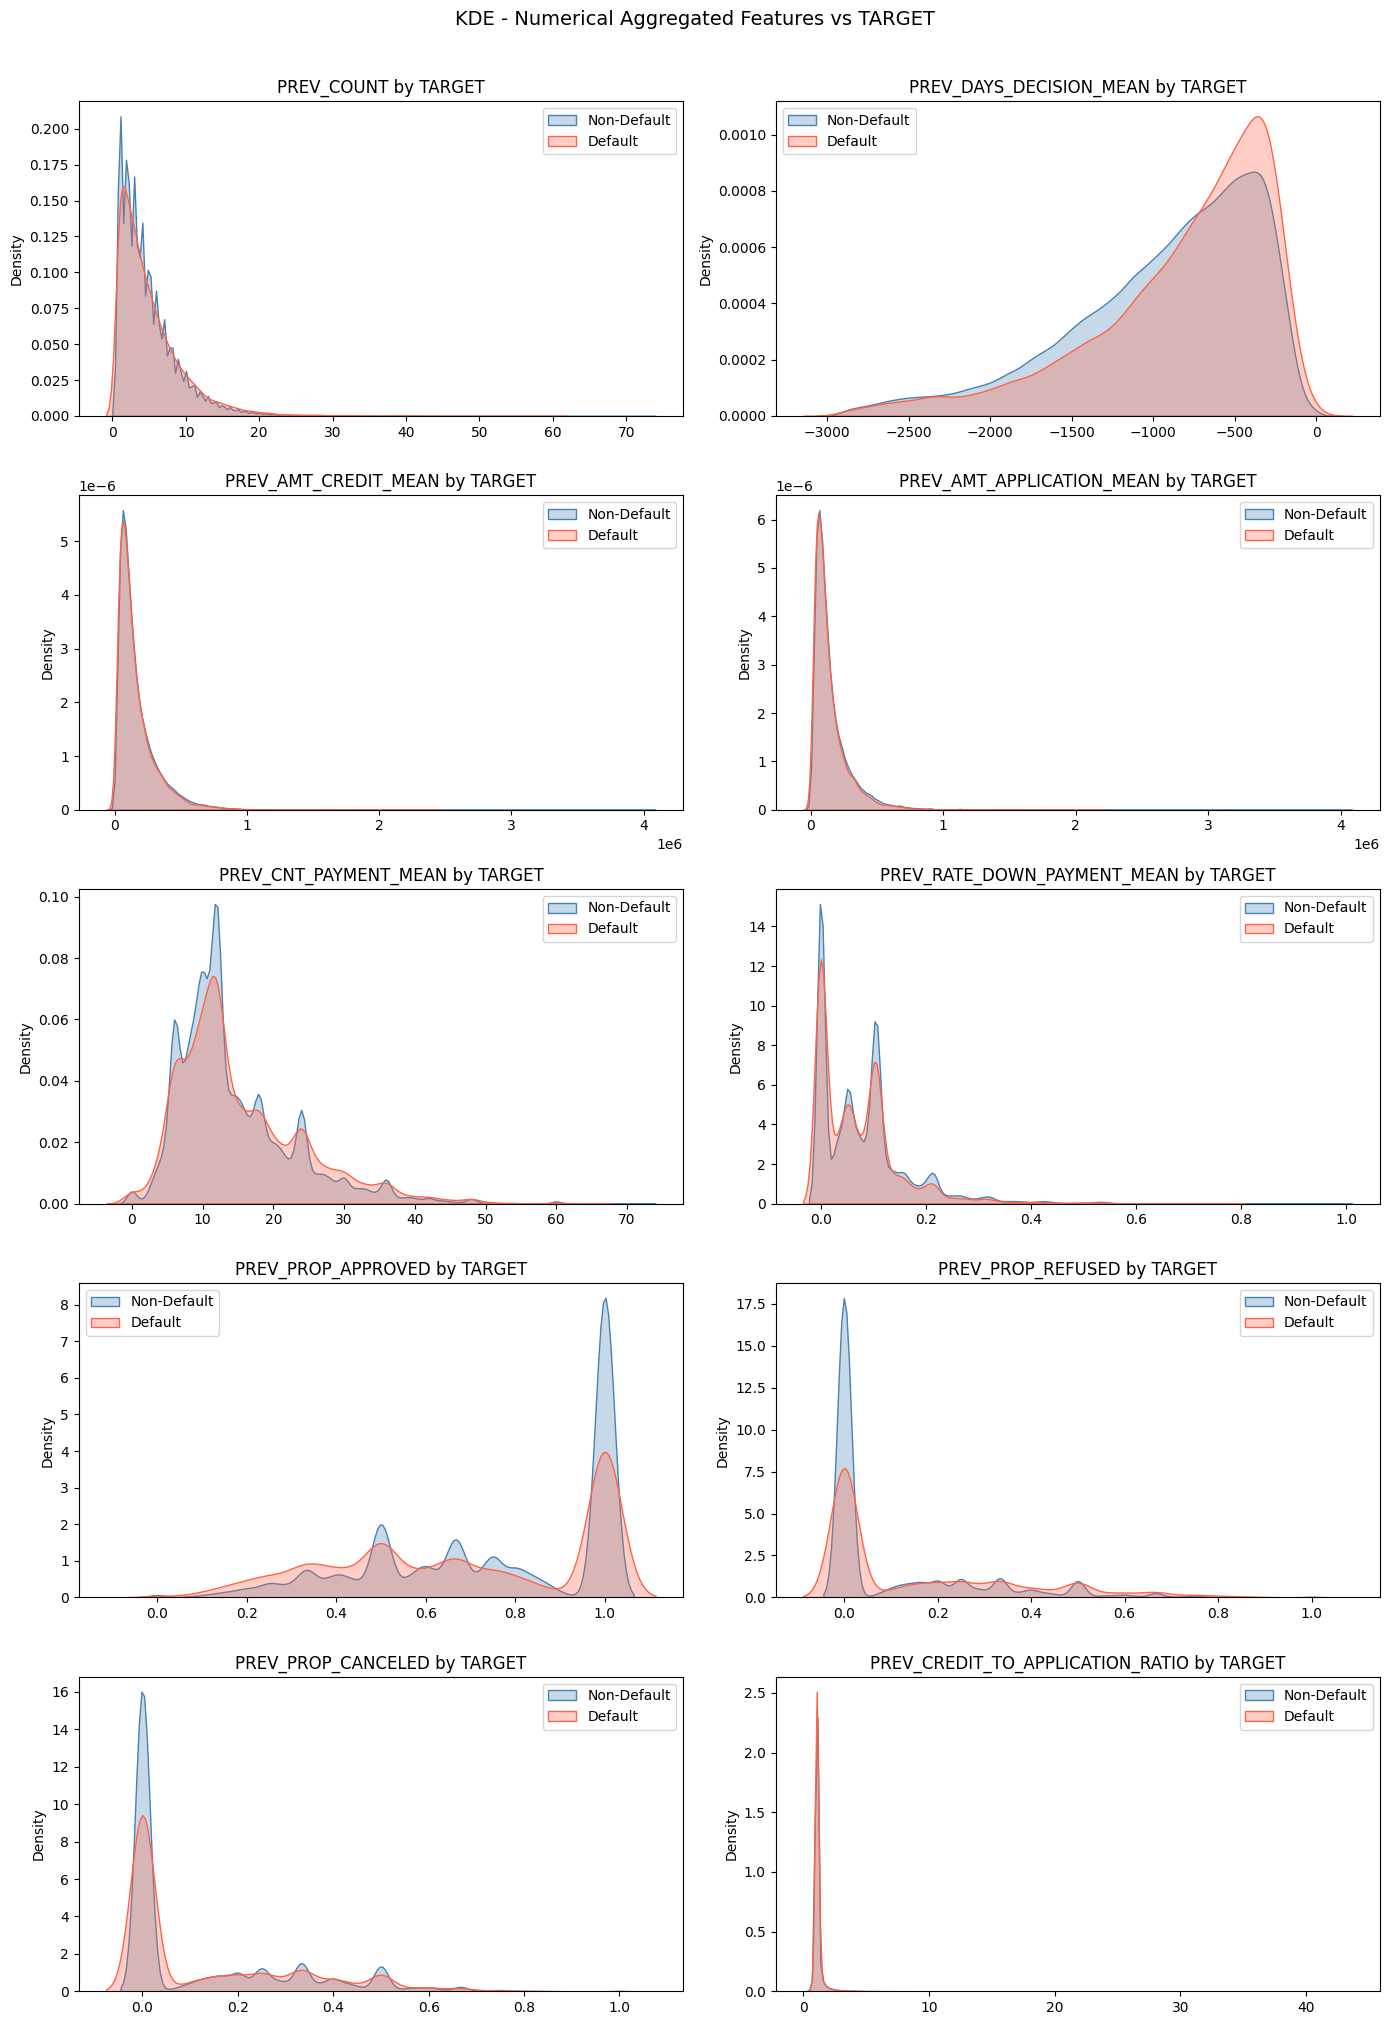

In [20]:
# Select key numerical aggregated features for bivariate analysis
num_agg_features = [
    'PREV_COUNT',
    'PREV_DAYS_DECISION_MEAN',
    'PREV_AMT_CREDIT_MEAN',
    'PREV_AMT_APPLICATION_MEAN',
    'PREV_CNT_PAYMENT_MEAN',
    'PREV_RATE_DOWN_PAYMENT_MEAN',
    'PREV_PROP_APPROVED',
    'PREV_PROP_REFUSED',
    'PREV_PROP_CANCELED',
    'PREV_CREDIT_TO_APPLICATION_RATIO'
]

# Grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(num_agg_features):
    for target_val, label, color in zip([0, 1], ['Non-Default', 'Default'], ['steelblue', 'tomato']):
        subset = df_prev_agg_target[df_prev_agg_target['TARGET'] == target_val][col].dropna()
        sns.kdeplot(subset, ax=axes[i], label=label, color=color, fill=True, alpha=0.3)
    axes[i].set_title(f'{col} by TARGET')
    axes[i].set_xlabel('')
    axes[i].legend()

plt.suptitle('KDE - Numerical Aggregated Features vs TARGET', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Key Findings - Numerical Aggregated Features

**PREV_COUNT**
Default applicants tend to have fewer previous applications, with both distributions concentrated near 1-5. Applicants with more previous applications are slightly more likely to be non-default, suggesting longer relationship history with Home Credit is associated with lower risk.

**PREV_DAYS_DECISION_MEAN**
Visible separation between classes. Default applicants show a distribution shifted toward more recent decisions (less negative values), while non-default applicants have older previous applications. More distant previous application history is associated with lower default risk.

**PREV_AMT_CREDIT_MEAN and PREV_AMT_APPLICATION_MEAN**
Both distributions are heavily compressed near zero with extreme right tails, making class separation difficult to observe visually. Outlier treatment is required before these features can be used effectively in modeling.

**PREV_CNT_PAYMENT_MEAN**
Visible separation between classes. Non-default applicants show higher counts at standard loan terms (12, 24 months), while default applicants show relatively more concentration at shorter terms. Longer average repayment terms may reflect more stable credit behavior.

**PREV_RATE_DOWN_PAYMENT_MEAN**
Both classes show similar distributions concentrated near zero with a secondary peak around 0.1-0.2. Limited discriminative power in raw form.

**PREV_PROP_APPROVED**
Non-default applicants show a stronger peak near 1.0 (all previous applications approved), while default applicants are more spread across lower approval proportions. Higher approval rate in previous applications is associated with lower current default risk.

**PREV_PROP_REFUSED**
Non-default applicants are heavily concentrated near 0 (no refusals), while default applicants show a heavier tail toward higher refusal proportions. History of refused applications is a meaningful predictor of current default risk.

**PREV_PROP_CANCELED**
Both classes show similar distributions with peaks near 0, but default applicants show slightly heavier tails. Moderate discriminative power.

**PREV_CREDIT_TO_APPLICATION_RATIO**
Both classes are heavily compressed near 1.0 with extreme outliers, making separation difficult to observe. Requires outlier treatment before use.

---

## 6.2 Categorical Aggregated Features

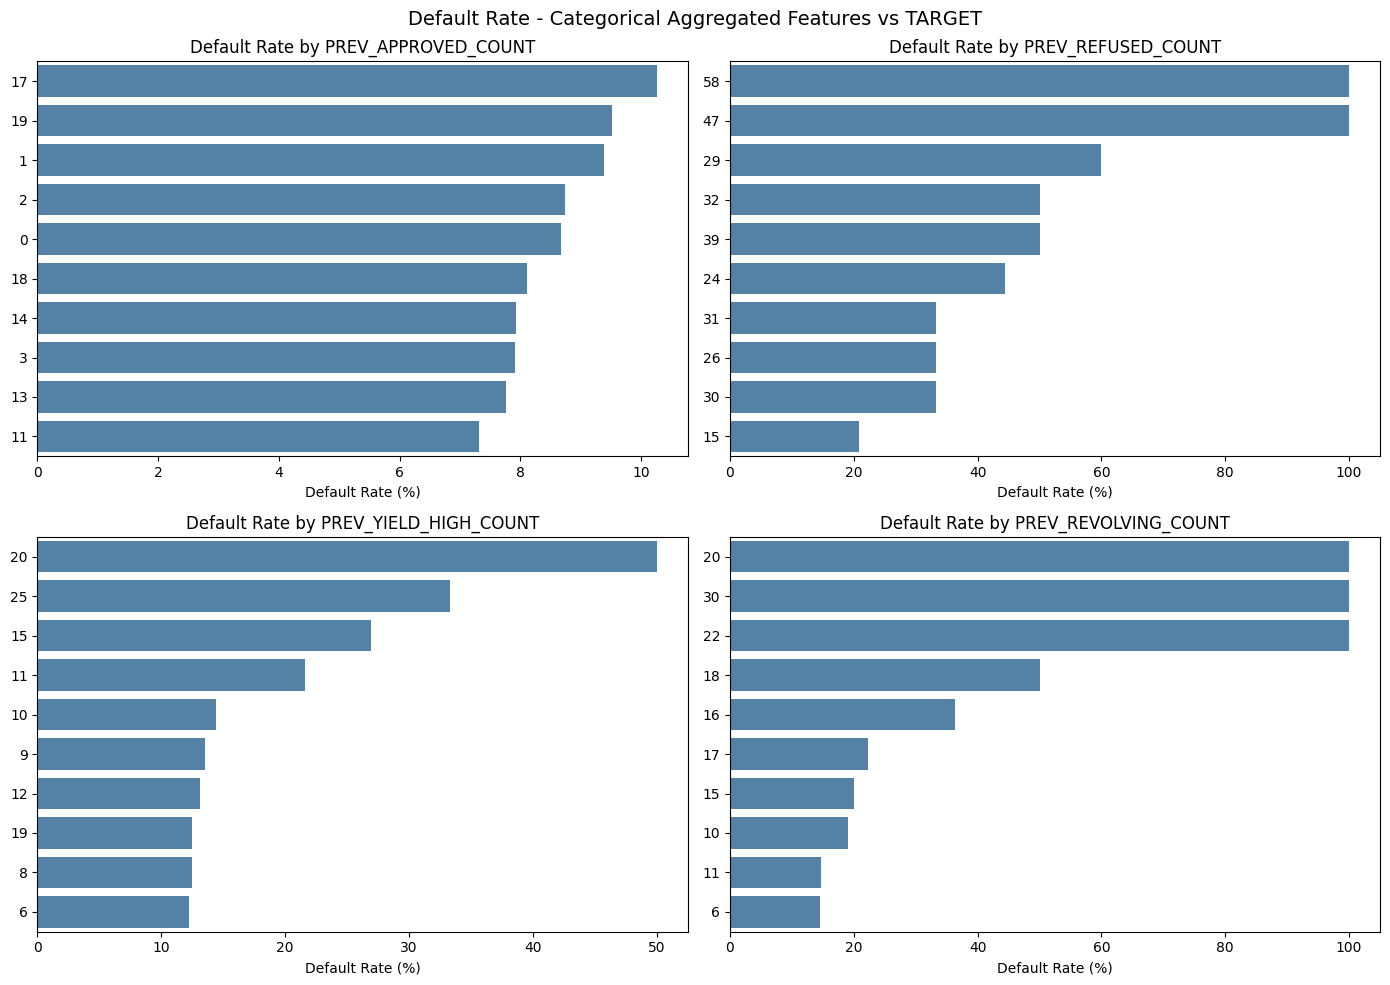

In [21]:
# Select categorical aggregated features for default rate analysis
cat_agg_features = [
    'PREV_APPROVED_COUNT',
    'PREV_REFUSED_COUNT',
    'PREV_YIELD_HIGH_COUNT',
    'PREV_REVOLVING_COUNT'
]

# Grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_agg_features):
    default_rate = df_prev_agg_target.groupby(col)['TARGET'].mean() * 100
    default_rate = default_rate.sort_values(ascending=False).head(10)
    sns.barplot(x=default_rate.values, y=default_rate.index.astype(str),
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].set_ylabel('')

plt.suptitle('Default Rate - Categorical Aggregated Features vs TARGET', fontsize=14)
plt.tight_layout()
plt.show()

#### Key Findings - Categorical Aggregated Features

**PREV_APPROVED_COUNT**
Non-linear relationship where very high approved counts (17, 19) show elevated default rates (~50-67%), while moderate counts (11-14) show lower rates (~7-8%). Extreme approval counts may indicate aggressive borrowing behavior associated with higher risk.

**PREV_REFUSED_COUNT**
Strong monotonic relationship where higher refused counts are associated with dramatically higher default rates. Applicants with 47-58 previous refusals show default rates approaching 100%, confirming prior rejection history as one of the strongest predictors of current default risk.

**PREV_YIELD_HIGH_COUNT**
Clear positive relationship where higher counts of high-yield previous applications are associated with higher default rates, reaching ~50% at 20 high-yield applications. Applicants repeatedly taking high-interest loans carry significantly elevated risk.

**PREV_REVOLVING_COUNT**
Applicants with very high revolving loan counts (20, 22, 30) show default rates approaching 100%, while those with moderate counts (6-11) show rates around 15-20%. High revolving credit usage is a strong indicator of financial overextension and default risk.

---

# 7. Insights & Recommendations


## 7.1 Key Findings

**Previous Application Coverage**
338,857 unique applicants have previous application records, covering approximately 110% of `application_train` applicants, indicating some applicants have previous records but no current training label. After merging, applicants with no previous application history should be handled with appropriate imputation.

**Refusal History is the Strongest Signal**
`PREV_REFUSED_COUNT` and `PREV_PROP_REFUSED` show the clearest separation between default and non-default applicants. Applicants with high previous refusal counts show default rates approaching 100%, confirming prior rejection history as one of the most predictive signals available in this dataset.

**Revolving and High-Yield Loan Patterns**
Applicants with high counts of revolving loans and high-yield group applications show dramatically elevated default rates. These patterns suggest financial overextension and repeated high-risk borrowing behavior that strongly correlates with current default risk.

**Approval Proportion as Behavioral Signal**
`PREV_PROP_APPROVED` shows meaningful separation, with non-default applicants having a higher proportion of approved previous applications. Combined with `PREV_PROP_REFUSED` and `PREV_PROP_CANCELED`, these proportion features capture the overall credit acceptance profile of each applicant.

**Recency of Previous Applications**
`PREV_DAYS_DECISION_MEAN` shows visible class separation, with default applicants having more recent previous applications. This suggests applicants who applied more recently may be in a more financially stressed state compared to those with older application histories.

**Amount Features Require Treatment**
`PREV_AMT_CREDIT_MEAN`, `PREV_AMT_APPLICATION_MEAN`, and `PREV_AMT_GOODS_PRICE_MEAN` are heavily right-skewed with extreme outliers. These features require capping or log transformation before being used effectively in modeling.

**Near-Constant Features**
`FLAG_LAST_APPL_PER_CONTRACT` (99.49% Y) and `NFLAG_LAST_APPL_IN_DAY` (99.65% 1) have near-zero variance and are unlikely to contribute meaningful signal after aggregation.

---

## 7.2 Recommended Aggregated Features

**Count and Proportion Features:**
- `PREV_COUNT`: total number of previous applications per applicant
- `PREV_APPROVED_COUNT`, `PREV_REFUSED_COUNT`, `PREV_CANCELED_COUNT`: application outcome counts
- `PREV_PROP_APPROVED`, `PREV_PROP_REFUSED`, `PREV_PROP_CANCELED`: application outcome proportions
- `PREV_REVOLVING_COUNT`: count of revolving loan applications
- `PREV_YIELD_HIGH_COUNT`: count of high-yield previous applications

**Temporal Features:**
- `PREV_DAYS_DECISION_MEAN`, `PREV_DAYS_DECISION_MIN`, `PREV_DAYS_DECISION_MAX`: recency and range of previous application decisions

**Amount Features:**
- `PREV_AMT_CREDIT_MEAN`, `PREV_AMT_CREDIT_SUM`: previous credit exposure
- `PREV_AMT_APPLICATION_MEAN`: average requested amount
- `PREV_CNT_PAYMENT_MEAN`: average repayment term length
- `PREV_RATE_DOWN_PAYMENT_MEAN`: average down payment rate

**Derived Features Recommended:**
- `PREV_HAS_REFUSED`: binary flag (1 if `PREV_REFUSED_COUNT` >= 1)
- `PREV_HAS_REVOLVING`: binary flag (1 if `PREV_REVOLVING_COUNT` >= 1)
- `PREV_CREDIT_TO_APPLICATION_RATIO`: credit granted vs amount requested ratio

---

## 7.3 Handling Strategy

**Missing Values after Merge:**
- Applicants with no previous application records will have all `PREV_*` features as NaN after merging. Impute with **0** for count and proportion features, as absence of previous application history is a meaningful signal in itself.
- `PREV_AMT_ANNUITY_MEAN`, `PREV_AMT_DOWN_PAYMENT_MEAN`, `PREV_RATE_DOWN_PAYMENT_MEAN`: impute with **0** for applicants with no previous applications, and **median** for those with records but missing values.

**Outlier Treatment:**
- `PREV_AMT_CREDIT_MEAN`, `PREV_AMT_APPLICATION_MEAN`, `PREV_AMT_GOODS_PRICE_MEAN`: cap at 99th percentile or apply log transformation
- `PREV_CREDIT_TO_APPLICATION_RATIO`: investigate and clip extreme values before use

**Low-Signal Features:**
- `RATE_INTEREST_PRIMARY`, `RATE_INTEREST_PRIVILEGED`: drop due to 99.64% missing rate
- `FLAG_LAST_APPL_PER_CONTRACT`, `NFLAG_LAST_APPL_IN_DAY`: consider dropping due to near-constant distribution
- `NAME_CASH_LOAN_PURPOSE`: consider dropping or grouping due to XAP/XNA dominance (~96%)

**All transformations and imputations to be implemented in `Data Cleaning and Handling.ipynb`.**

---

In [22]:
# Read markdown cells from notebook
import json

with open('EDA_previous_application.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'markdown':
        print(f"--- Cell {i} ---")
        print(''.join(cell['source']))
        print()

--- Cell 0 ---
# Exploratory Data Analysis (EDA)
## Dataset: previous_application

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `previous_application` dataset from the Home Credit risk modeling case. This table contains all previous loan applications submitted by clients who have a current loan in the sample, serving as a behavioral history signal for predicting default on the current application.

---

## 🎯 Objectives
- Understand the structure and characteristics of the `previous_application` dataset
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main ta